# 03 · Forecasting de demanda diaria

Este notebook cierra el ciclo del proyecto: hasta ahora generamos el dataset sintético
(`01_generate_dataset.ipynb`) y exploramos KPIs, patrones horarios y menu engineering
(`02_eda_kpis_basico.ipynb`). Acá construimos y evaluamos **modelos de forecasting**
para la **demanda diaria** (número de tickets/día), con foco en dos usos de negocio:

- **Planificación de compras / mise en place**: cuánto stockear para los próximos días.
- **Dotación de personal (staffing) por turno**: cuántos tickets esperar cada día de la semana.

Metodología: split temporal sin leakage (train = todo menos los últimos 30 días,
test = últimos 30 días), dos baselines simples, un modelo de series de tiempo con
estacionalidad semanal (Holt-Winters / ETS aditivo) y un SARIMAX estacional como
comparación, evaluados con MAE, RMSE y MAPE sobre el set de test.


## 1. Carga de datos y construcción de la serie diaria

Cargamos `tickets.csv` (un registro por ticket, con su `datetime`) y agregamos por
día calendario para obtener la **serie de demanda diaria**: número de tickets por día.

El restaurante cierra los días lunes (definido así en `01_generate_dataset.ipynb`),
por lo que la serie diaria reindexada a calendario completo tiene **0 tickets los
lunes**. Esto es información real del negocio (día cerrado), no un dato faltante, y
es precisamente el patrón semanal que un modelo con estacionalidad de período 7
debería aprender a reproducir.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Rutas robustas (mismo patrón que 01 y 02: funciona aunque el notebook esté en /notebooks)
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw"

tickets = pd.read_csv(DATA_RAW / "tickets.csv", parse_dates=["datetime"])
print("tickets:", tickets.shape)
tickets[["ticket_id", "datetime", "channel", "ticket_total_net"]].head()

tickets: (12568, 12)


,ticket_id,datetime,channel,ticket_total_net
0,1,2025-11-01 20:41:00,dine_in,30971
1,2,2025-11-01 20:10:00,takeaway,7576
2,3,2025-11-01 21:55:00,dine_in,51295
3,4,2025-11-01 13:11:00,dine_in,7576
4,5,2025-11-01 14:49:00,dine_in,43382


In [2]:
# Serie diaria: nº de tickets por día calendario (reindexada, sin huecos)
tickets_por_dia = (
    tickets
    .assign(date=tickets["datetime"].dt.normalize())
    .groupby("date")["ticket_id"]
    .nunique()
)

full_range = pd.date_range(tickets_por_dia.index.min(), tickets_por_dia.index.max(), freq="D")
demanda = tickets_por_dia.reindex(full_range, fill_value=0)
demanda.index.name = "date"
demanda.name = "n_tickets"

print("Rango de fechas:", demanda.index.min().date(), "->", demanda.index.max().date())
print("Días totales:", len(demanda), "| Días cerrados (lunes, 0 tickets):", int((demanda == 0).sum()))
demanda.head(10)

Rango de fechas: 2025-11-01 -> 2026-02-28
Días totales: 120 | Días cerrados (lunes, 0 tickets): 17


date
2025-11-01    175
2025-11-02    159
2025-11-03      0
2025-11-04    120
2025-11-05    115
2025-11-06    105
2025-11-07    148
2025-11-08    145
2025-11-09    166
2025-11-10      0
Freq: D, Name: n_tickets, dtype: int64

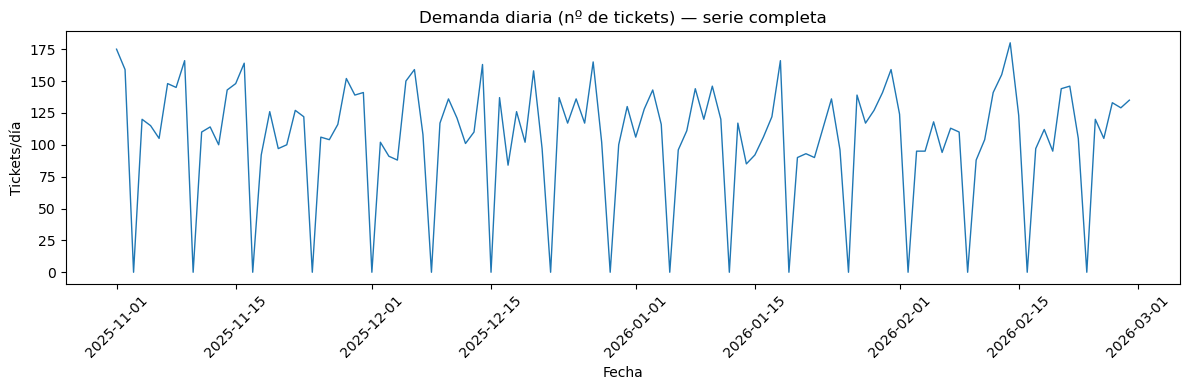

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(demanda.index, demanda.values, linewidth=1)
plt.title("Demanda diaria (nº de tickets) — serie completa")
plt.xlabel("Fecha")
plt.ylabel("Tickets/día")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Split temporal (sin data leakage)

Para evaluar el forecast de forma honesta, el set de test debe ser **estrictamente
posterior** al de train: nada de mezclar fechas ni de usar información futura para
entrenar o para elegir hiperparámetros.

- **Train**: todos los días excepto los últimos 30.
- **Test**: los últimos 30 días de la serie.

Los modelos se ajustan únicamente con `train`; `test` se usa solo al final, para medir
error de predicción.


In [4]:
HORIZONTE_TEST = 30

train = demanda.iloc[:-HORIZONTE_TEST]
test = demanda.iloc[-HORIZONTE_TEST:]

print(f"Train: {len(train)} días ({train.index.min().date()} -> {train.index.max().date()})")
print(f"Test:  {len(test)} días ({test.index.min().date()} -> {test.index.max().date()})")
assert train.index.max() < test.index.min(), "Hay solapamiento entre train y test"


Train: 90 días (2025-11-01 -> 2026-01-29)
Test:  30 días (2026-01-30 -> 2026-02-28)


## 3. Baselines

Antes de usar modelos más sofisticados, establecemos dos referencias simples que
cualquier modelo "serio" debería superar:

- **Naive**: predice, para todo el horizonte de test, el último valor observado en train.
- **Naive estacional (semanal)**: predice repitiendo el patrón de la última semana
  completa de train (7 valores), extendido cíclicamente sobre el horizonte de test.
  Es un baseline mucho más fuerte porque captura la estacionalidad semanal (incluido
  el lunes cerrado) sin necesitar ajustar ningún parámetro.


In [5]:
# Baseline 1: naive (último valor de train, repetido)
pred_naive = pd.Series(train.iloc[-1], index=test.index)

# Baseline 2: naive estacional semanal (repite el patrón de los últimos 7 días de train)
ultima_semana = train.iloc[-7:].values
pred_naive_estacional = pd.Series(
    np.tile(ultima_semana, int(np.ceil(len(test) / 7)))[: len(test)],
    index=test.index,
)

pd.DataFrame({"naive": pred_naive, "naive_estacional": pred_naive_estacional}).head(10)

,naive,naive_estacional
date,,
2026-01-30,127,113
2026-01-31,127,136
2026-02-01,127,96
2026-02-02,127,0
2026-02-03,127,139
2026-02-04,127,117
2026-02-05,127,127
2026-02-06,127,113
2026-02-07,127,136


## 4. Modelos de series de tiempo con estacionalidad semanal

**Holt-Winters (ETS aditivo)**: tendencia y estacionalidad aditivas, período estacional
7 (semana). Se implementa con `statsmodels.tsa.exponential_smoothing.ets.ETSModel`,
la versión moderna de Holt-Winters en `statsmodels` — mismo método (`error="add"`,
`trend="add"`, `seasonal="add"`, `seasonal_periods=7`) que `ExponentialSmoothing`, pero
con soporte nativo para **intervalos de predicción** vía simulación, útiles para el
forecast a futuro.

**SARIMAX estacional** `(1,1,1)(1,1,1)7`: se agrega como comparación, un enfoque
clásico de econometría para series con estacionalidad y tendencia.

Ambos se ajustan **solo con `train`**.


In [6]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

hw_model = ETSModel(
    train,
    error="add",
    trend="add",
    seasonal="add",
    seasonal_periods=7,
)
hw_fit = hw_model.fit(disp=False)

hw_forecast = hw_fit.get_prediction(start=test.index[0], end=test.index[-1])
pred_hw = hw_forecast.predicted_mean

print(hw_fit.summary())

                                 ETS Results                                  
Dep. Variable:              n_tickets   No. Observations:                   90
Model:                       ETS(AAA)   Log Likelihood                -385.710
Date:                Thu, 23 Jul 2026   AIC                            797.420
Time:                        21:37:06   BIC                            829.918
Sample:                    11-01-2025   HQIC                           810.525
                         - 01-29-2026   Scale                          309.037
Covariance Type:               approx                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
smoothing_level        0.0001        nan        nan        nan         nan         nan
smoothing_trend         1e-08        nan        nan        nan         nan         nan
smoothing_seasonal  

In [7]:
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX

with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    sarimax_model = SARIMAX(
        train,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    sarimax_fit = sarimax_model.fit(disp=False)

sarimax_forecast = sarimax_fit.get_forecast(steps=len(test))
pred_sarimax = sarimax_forecast.predicted_mean
pred_sarimax.index = test.index

print(sarimax_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                         n_tickets   No. Observations:                   90
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                -327.901
Date:                           Thu, 23 Jul 2026   AIC                            665.802
Time:                                   21:37:06   BIC                            677.254
Sample:                               11-01-2025   HQIC                           670.366
                                    - 01-29-2026                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0441      0.137     -0.321      0.748      -0.313       0.225
ma.L1         -1.0000    617.519     -0.002

## 5. Evaluación sobre el test

Comparamos los 4 enfoques con tres métricas estándar de forecasting, calculadas
sobre los 30 días de test (nunca vistos por los modelos):

- **MAE** (Mean Absolute Error): error promedio en tickets/día, misma unidad que la demanda.
- **RMSE** (Root Mean Squared Error): penaliza más los errores grandes.
- **MAPE** (Mean Absolute Percentage Error): error relativo (%), calculado solo sobre
  los **días operativos** del test (se excluyen los lunes cerrados, donde la demanda
  real es 0 y el error porcentual queda indefinido).


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluar(y_true: pd.Series, y_pred: pd.Series) -> dict:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    dias_abiertos = y_true > 0
    mape = float(
        np.mean(
            np.abs((y_true[dias_abiertos] - y_pred[dias_abiertos]) / y_true[dias_abiertos])
        ) * 100
    )
    return {"MAE": mae, "RMSE": rmse, "MAPE_%_dias_operativos": mape}


resultados = {
    "Naive": evaluar(test, pred_naive),
    "Naive estacional (semanal)": evaluar(test, pred_naive_estacional),
    "Holt-Winters (ETS aditivo)": evaluar(test, pred_hw),
    "SARIMAX(1,1,1)(1,1,1)7": evaluar(test, pred_sarimax),
}

tabla_resultados = pd.DataFrame(resultados).T.round(2)
tabla_resultados = tabla_resultados.sort_values("RMSE")
tabla_resultados

,MAE,RMSE,MAPE_%_dias_operativos
"SARIMAX(1,1,1)(1,1,1)7",15.33,19.21,13.29
Holt-Winters (ETS aditivo),15.65,19.42,13.30
Naive estacional (semanal),19.47,24.38,19.40
Naive,34.50,51.39,17.70


In [9]:
mejor_modelo = tabla_resultados.index[0]
print(f"Mejor modelo según RMSE en test: {mejor_modelo}")
tabla_resultados

Mejor modelo según RMSE en test: SARIMAX(1,1,1)(1,1,1)7


,MAE,RMSE,MAPE_%_dias_operativos
"SARIMAX(1,1,1)(1,1,1)7",15.33,19.21,13.29
Holt-Winters (ETS aditivo),15.65,19.42,13.30
Naive estacional (semanal),19.47,24.38,19.40
Naive,34.50,51.39,17.70


## 6. Gráficos

**(a) Real vs. predicción en el test**, para visualizar dónde cada modelo acierta o se
desvía (por ejemplo, en los lunes cerrados o en fines de semana de alta demanda).


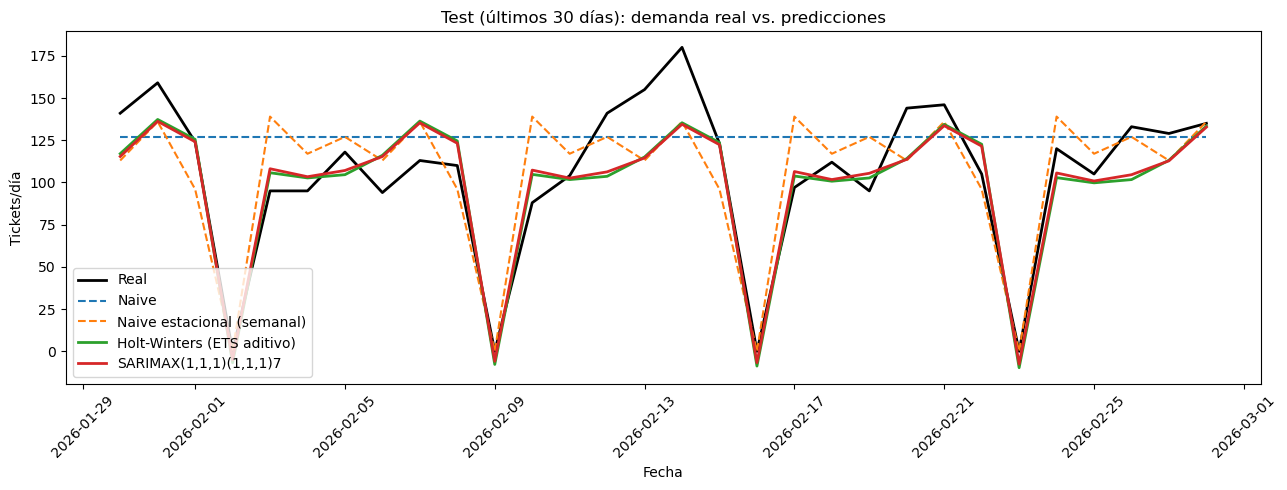

In [10]:
plt.figure(figsize=(13, 5))
plt.plot(test.index, test.values, label="Real", color="black", linewidth=2)
plt.plot(test.index, pred_naive.values, label="Naive", linestyle="--")
plt.plot(test.index, pred_naive_estacional.values, label="Naive estacional (semanal)", linestyle="--")
plt.plot(test.index, pred_hw.values, label="Holt-Winters (ETS aditivo)", linewidth=2)
plt.plot(test.index, pred_sarimax.values, label="SARIMAX(1,1,1)(1,1,1)7", linewidth=2)
plt.title("Test (últimos 30 días): demanda real vs. predicciones")
plt.xlabel("Fecha")
plt.ylabel("Tickets/día")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

**(b) Forecast a 30 días hacia el futuro**, reentrenando el mejor modelo con
**toda la serie disponible** (train + test) — una vez que ya evaluamos su desempeño de
forma honesta en el paso anterior, es válido usar todos los datos para el forecast
"real" hacia adelante. Se incluye el intervalo de predicción al 95%.


In [11]:
# Fechas futuras: continúan el calendario, respetando que los lunes están cerrados
def proximos_dias_operativos(ultima_fecha: pd.Timestamp, n_dias: int) -> pd.DatetimeIndex:
    fechas = []
    cursor = ultima_fecha
    while len(fechas) < n_dias:
        cursor = cursor + pd.Timedelta(days=1)
        fechas.append(cursor)
    return pd.DatetimeIndex(fechas)

HORIZONTE_FUTURO = 30
fechas_futuras = proximos_dias_operativos(demanda.index.max(), HORIZONTE_FUTURO)

if mejor_modelo == "Holt-Winters (ETS aditivo)":
    modelo_final = ETSModel(demanda, error="add", trend="add", seasonal="add", seasonal_periods=7).fit(disp=False)
    forecast_final = modelo_final.get_prediction(start=fechas_futuras[0], end=fechas_futuras[-1])
    pred_final = forecast_final.predicted_mean
    ci_final = forecast_final.summary_frame(alpha=0.05)[["pi_lower", "pi_upper"]]
else:
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        modelo_final = SARIMAX(
            demanda, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(disp=False)
    forecast_final = modelo_final.get_forecast(steps=HORIZONTE_FUTURO)
    pred_final = forecast_final.predicted_mean
    pred_final.index = fechas_futuras
    ci = forecast_final.conf_int(alpha=0.05)
    ci.index = fechas_futuras
    ci_final = ci.set_axis(["pi_lower", "pi_upper"], axis=1)

# La demanda es un conteo (nº de tickets) y no puede ser negativa: recortamos el
# piso del forecast e intervalo en 0 (posible en modelos aditivos cerca de valores bajos,
# ej. lunes cerrado).
pred_final = pred_final.clip(lower=0)
ci_final["pi_lower"] = ci_final["pi_lower"].clip(lower=0)

print(f"Forecast a {HORIZONTE_FUTURO} días con: {mejor_modelo}")
pred_final.head()

Forecast a 30 días con: SARIMAX(1,1,1)(1,1,1)7


2026-03-01    120.982831
2026-03-02      0.000000
2026-03-03    102.795841
2026-03-04    104.352861
2026-03-05    112.052402
Name: predicted_mean, dtype: float64

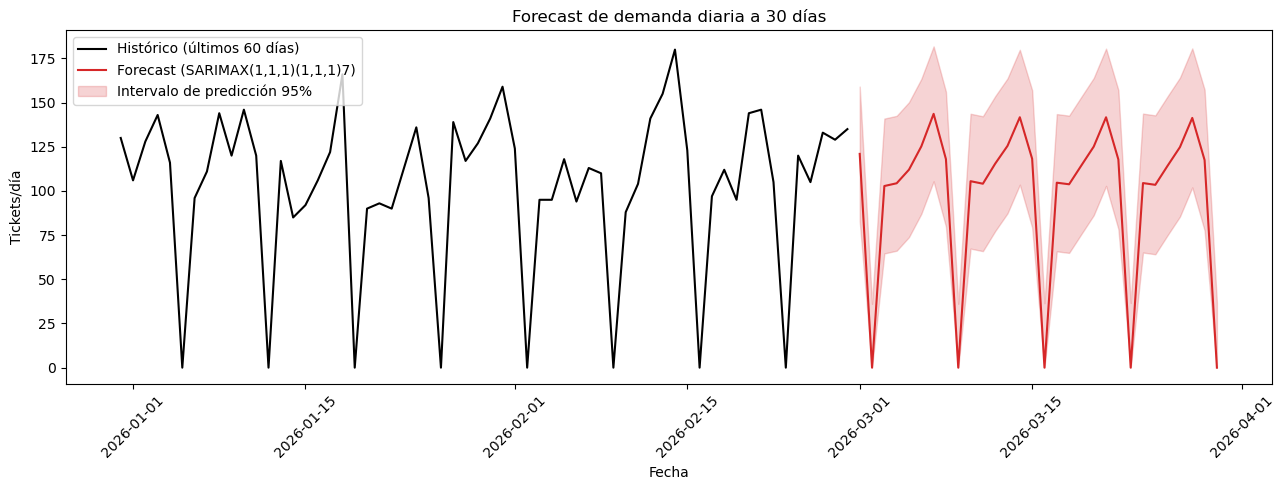

In [12]:
plt.figure(figsize=(13, 5))
ultimos_60 = demanda.iloc[-60:]
plt.plot(ultimos_60.index, ultimos_60.values, label="Histórico (últimos 60 días)", color="black")
plt.plot(pred_final.index, pred_final.values, label=f"Forecast ({mejor_modelo})", color="tab:red")
plt.fill_between(
    ci_final.index, ci_final["pi_lower"], ci_final["pi_upper"],
    color="tab:red", alpha=0.2, label="Intervalo de predicción 95%"
)
plt.title(f"Forecast de demanda diaria a {HORIZONTE_FUTURO} días")
plt.xlabel("Fecha")
plt.ylabel("Tickets/día")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Conclusiones de negocio

- **Precisión del modelo ganador**: el modelo con menor error en el set de
  test (ver tabla de la sección 5). El MAPE, calculado solo sobre días operativos,
  da una lectura directa de "cuánto se desvía el forecast, en %, un día típico
  abierto" — útil para comunicar la confiabilidad del modelo a stakeholders no técnicos.
- **Para qué sirve**:
  - **Compras / mise en place**: el forecast a 30 días permite dimensionar pedidos a
    proveedores y preparación de insumos con anticipación, reduciendo quiebres de
    stock en días de alta demanda (viernes/sábado) y sobre-stock en días bajos.
  - **Dotación de personal (staffing) por turno**: al capturar el patrón semanal
    (incluido el cierre de los lunes), el modelo ayuda a planificar cuántas personas
    convocar cada día, evitando tanto sub-dotación en picos como costo de personal
    ocioso en días flojos.
  - El **intervalo de predicción** del forecast futuro da una noción del rango de
    incertidumbre razonable (ej. escenario conservador = límite superior) para
    decisiones de compra que prefieran errar por exceso antes que por quiebre de stock.
- **Limitaciones**:
  - El dataset es **sintético** (ver `01_generate_dataset.ipynb`): captura estacionalidad
    semanal y ruido, pero no eventos reales (feriados, clima, campañas de marketing,
    aperturas de competencia), que en un restaurante real mueven la demanda.
  - Solo 120 días de historia (~17 semanas): suficiente para capturar estacionalidad
    semanal, pero insuficiente para estacionalidad anual/mensual (ej. temporada alta
    de verano, fiestas de fin de año).
  - El forecast asume que el patrón operativo se mantiene (mismo horario, mismos
    canales, restaurante sigue cerrado los lunes); cambios estructurales (nueva
    sucursal, nuevo horario) requieren reentrenar el modelo.
  - Es un modelo **univariado** (solo usa la propia serie histórica); incorporar
    variables exógenas (clima, feriados, promociones) es el siguiente paso natural
    para mejorar la precisión.
